In [1]:
suppressMessages(library(ArchR))
suppressMessages(library(Seurat))
suppressMessages(library(Signac))
suppressMessages(library(ggplot2))
suppressMessages(library(cowplot))
suppressMessages(library(rtracklayer))

In [2]:
addArchRThreads(threads = 32)

Setting default number of Parallel threads to 32.



In [3]:
in_dir = '../../results/04_single_cell_access_atac/22_find_markers'
out_dir = '../../results/04_single_cell_access_atac/23_final_annotation'

# create output directory
if (!dir.exists(out_dir)) {
  dir.create(out_dir, recursive = TRUE)
}

In [4]:
obj <- readRDS(glue::glue("{in_dir}/seurat_atac_obj_with_marker_scores.Rds"))

In [7]:
colnames(obj@meta.data)

[1] "orig.ident"                     "nCount_ATAC"                   
 [3] "nFeature_ATAC"                  "Sample"                        
 [5] "TSSEnrichment"                  "ReadsInTSS"                    
 [7] "ReadsInPromoter"                "PromoterRatio"                 
 [9] "PassQC"                         "NucleosomeRatio"               
[11] "nMultiFrags"                    "nMonoFrags"                    
[13] "nFrags"                         "nDiFrags"                      
[15] "DoubletScore"                   "DoubletEnrichment"             
[17] "ReadsInPeaks"                   "FRIP"                          
[19] "nFrags_log10"                   "ATAC_snn_res.1"                
[21] "seurat_clusters"                "nCount_GeneActivity"           
[23] "nFeature_GeneActivity"          "Basal_Marker_Score_1"          
[25] "Basal_Marker_Score_2"           "Basal_Marker_Score_3"          
[27] "Basal_Marker_Score_4"           "Basal_Marker_Score_5"          
[29] "Basal_Marker_Score_6"           "Basal_Marker_Score_7"          
[31] "Basal_Marker_Score_8"           "Basal_Marker_Score_9"          
[33] "Basal_Marker_Score_10"          "Basal_Marker_Score_11"         
[35] "Basal_Marker_Score_12"          "Basal_Marker_Score_13"         
[37] "Basal_Marker_Score_14"          "Basal_Marker_Score_15"         
[39] "Basal_Marker_Score_16"          "Basal_Marker_Score_17"         
[41] "Basal_Marker_Score_18"          "Basal_Marker_Score_19"         
[43] "Basal_Marker_Score_20"          "Basal_Marker_Score_21"         
[45] "Basal_Marker_Score_22"          "Basal_Marker_Score_23"         
[47] "Basal_Marker_Score_24"          "Basal_Marker_Score_25"         
[49] "Basal_Marker_Score_26"          "Basal_Marker_Score_27"         
[51] "Basal_Marker_Score_28"          "Basal_Marker_Score_29"         
[53] "Basal_Marker_Score_30"          "Basal_Marker_Score_31"         
[55] "Basal_Marker_Score_32"          "Basal_Marker_Score_33"         
[57] "Basal_Marker_Score_34"          "Basal_Marker_Score_35"         
[59] "Basal_Marker_Score_36"          "Basal_Marker_Score_37"         
[61] "Basal_Marker_Score_38"          "Basal_Marker_Score_39"         
[63] "Basal_Marker_Score_40"          "Basal_Marker_Score_41"         
[65] "Basal_Marker_Score_42"          "Basal_Marker_Score_43"         
[67] "Basal_Marker_Score_44"          "Basal_Marker_Score_45"         
[69] "Basal_Marker_Score_46"          "Basal_Marker_Score_47"         
[71] "Basal_Marker_Score_48"          "Basal_Marker_Score_49"         
[73] "Basal_Marker_Score_50"          "Club_Marker_Score_1"           
[75] "Ciliated_Marker_Score_1"        "Tuft_Marker_Score_1"           
[77] "Neuroendocrine_Marker_Score_1"  "Ionocyte_Marker_Score_1"       
[79] "Goblet_Marker_Score_1"          "Hillock_Marker_Score_1"        
[81] "Hillock_luminal_Marker_Score_1" "Hillock2_Marker_Score_1"

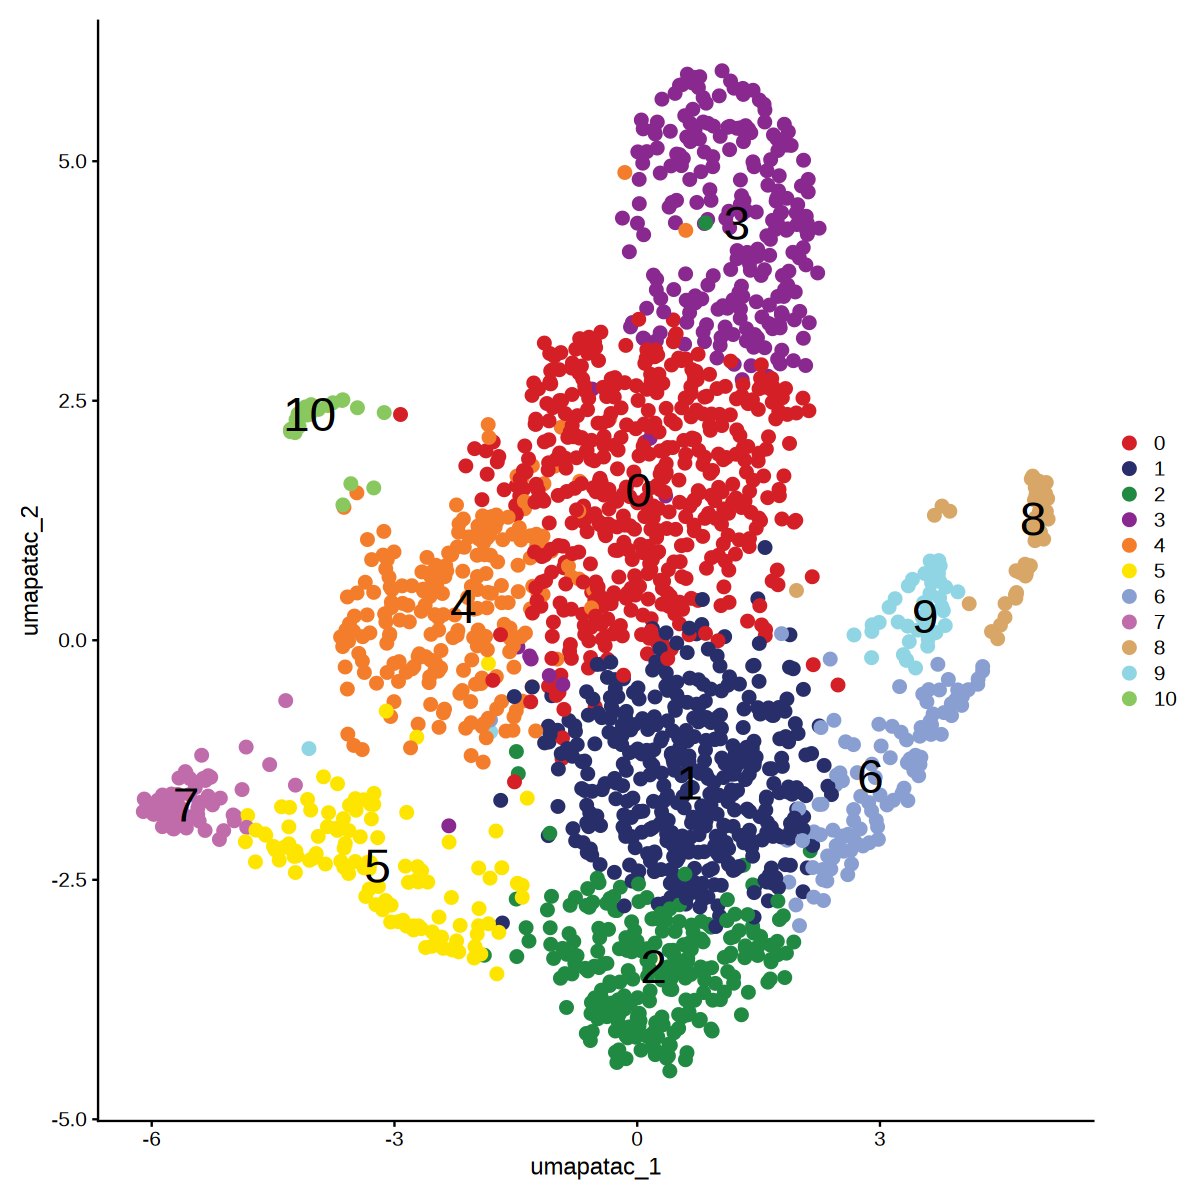

In [11]:
options(repr.plot.height = 10, repr.plot.width = 10)

p <- DimPlot(object = obj, label = TRUE, label.size = 10, pt.size = 3, 
cols = ArchR::paletteDiscrete(obj$seurat_clusters))

print(p)

In [13]:
obj@meta.data$cell_type_final <- stringr::str_replace_all(obj@meta.data$seurat_clusters, 
c("10" = "Basal", 
"1" = "Club", 
"2" = "Club", 
"3" = "Basal", 
"4" = "Basal", 
"5" = "Hillock", 
"6" = "Club", 
"7" = "Hillock", 
"8" = "Tuft/Neuroendocrine", 
"9" = "Ciliated", 
"0" = "Basal"))

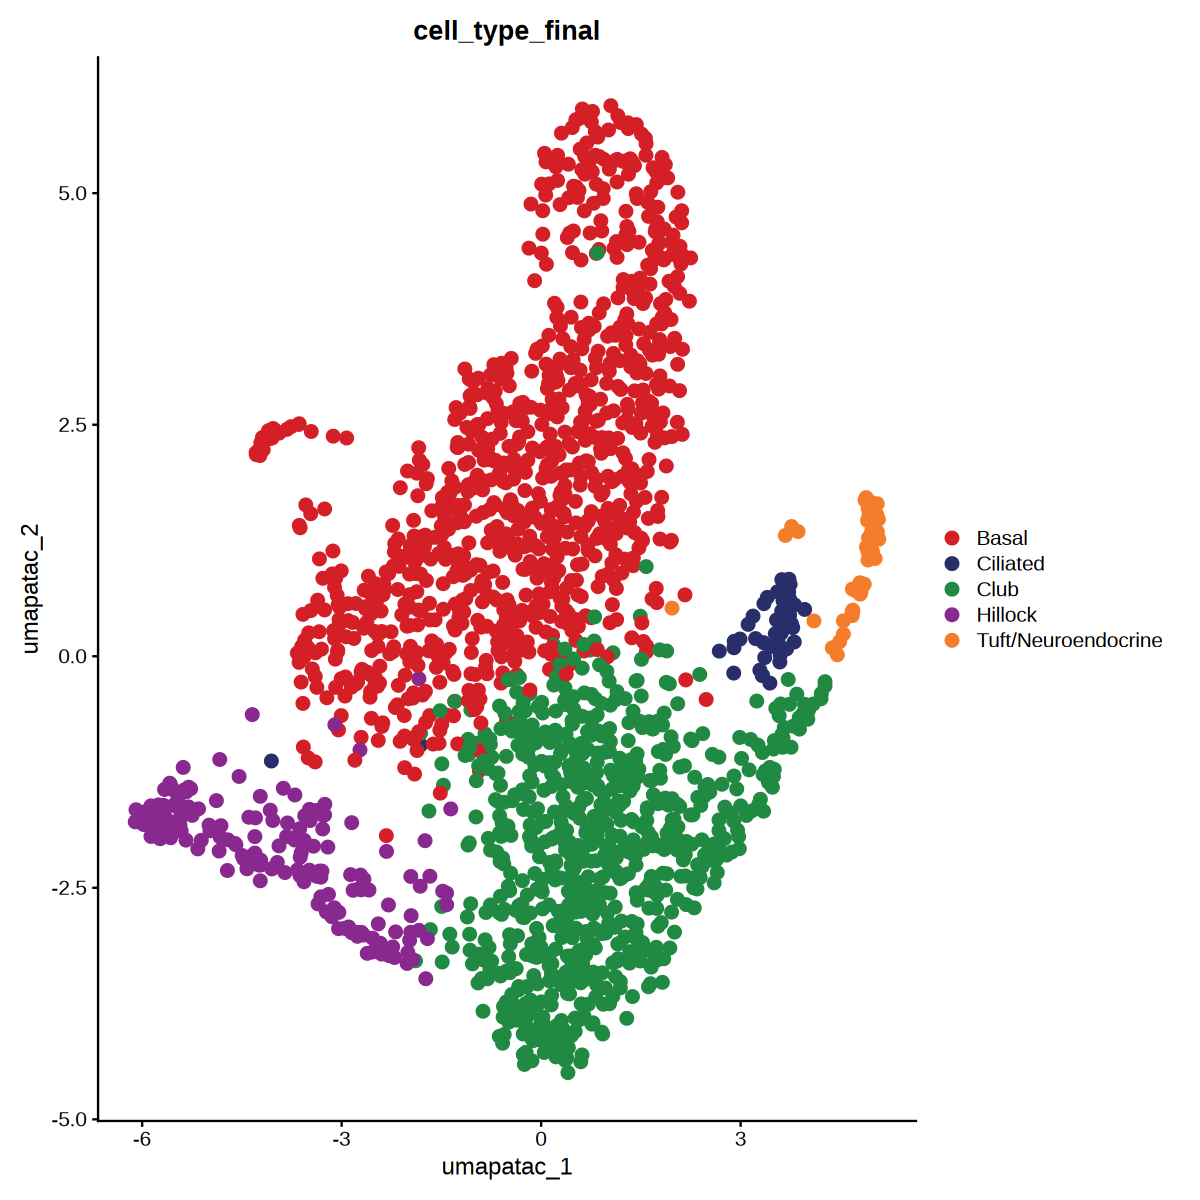

In [15]:
options(repr.plot.height = 10, repr.plot.width = 10)

p <- DimPlot(object = obj, group.by = "cell_type_final", label = FALSE, 
label.size = 10, pt.size = 3, 
cols = ArchR::paletteDiscrete(obj$cell_type_final))

print(p)

In [16]:
saveRDS(obj, file = glue::glue("{out_dir}/seurat_atac_obj_with_final_annotation.Rds"))